In [1]:
!pip install ultralytics opencv-python matplotlib labelImg

In [2]:
import os

image_path = "data"
print(len(os.listdir(image_path)))

481


In [5]:
import os

# Create folder structure
os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/images/val", exist_ok=True)
os.makedirs("dataset/labels/train", exist_ok=True)
os.makedirs("dataset/labels/val", exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [6]:
import xml.etree.ElementTree as ET
import os

xml_path = "data/annotations.xml"
output_dir = "labels_temp"

os.makedirs(output_dir, exist_ok=True)

class_map = {
    "spalling": 0,
    "honeycombing": 1,
    "rebar": 2,
    "damage": 3
}

tree = ET.parse(xml_path)
root = tree.getroot()

for image in root.findall("image"):
    filename = image.get("name")
    width = float(image.get("width"))
    height = float(image.get("height"))

    txt_filename = filename.replace(".JPG", ".txt")
    txt_path = os.path.join(output_dir, txt_filename)

    with open(txt_path, "w") as f:
        for poly in image.findall("polygon"):
            label = poly.get("label")

            if label not in class_map:
                continue

            class_id = class_map[label]

            points = poly.get("points").split(";")

            yolo_points = []

            for p in points:
                x, y = map(float, p.split(","))

                # Normalize
                x = x / width
                y = y / height

                yolo_points.append(f"{x} {y}")

            line = f"{class_id} " + " ".join(yolo_points)
            f.write(line + "\n")

print("✅ Segmentation labels created!")

✅ Segmentation labels created!


In [7]:
print(os.listdir("labels_temp")[:5])

['MAX_0441.txt', 'MAX_0442.txt', 'MAX_0443.txt', 'MAX_0444.txt', 'MAX_0445.txt']


In [8]:
with open("labels_temp/MAX_0441.txt", "r") as f:
    print(f.read())

3 0.3487548828125 0.3524576822916667 0.339530029296875 0.3681819661458334 0.352176513671875 0.39191243489583333 0.388223876953125 0.4099300130208334 0.442667236328125 0.42223470052083334 0.5551025390625 0.426953125 0.605101318359375 0.418544921875 0.627005615234375 0.41410156249999996 0.645535888671875 0.40988606770833336 0.663455810546875 0.39605143229166667 0.673074951171875 0.38158203125 0.679617919921875 0.3511946614583333 0.669547119140625 0.34282877604166667 0.66588134765625 0.37109375 0.635086669921875 0.39415852864583334 0.546158447265625 0.4042659505208333 0.426007080078125 0.40361979166666667 0.370047607421875 0.38387207031250004
3 0.451439208984375 0.5617513020833333 0.412769775390625 0.6600716145833333 0.43974853515625 0.6840527343749999 0.5413671875 0.690048828125 0.613309326171875 0.6480810546875 0.576439208984375 0.5617513020833333 0.514388427734375 0.5689453125
1 0.4960107421875 0.46814615885416666 0.4829443359375 0.48105305989583336 0.49528564453125 0.4958935546875 0.5

In [10]:
import os
import random
import shutil

# Get images
images = [f for f in os.listdir("data") if f.endswith(".JPG")]

# Shuffle
random.shuffle(images)

# 80% train, 20% val
split = int(0.8 * len(images))

train_imgs = images[:split]
val_imgs = images[split:]

def copy_files(img_list, split):
    for img in img_list:
        label = img.replace(".JPG", ".txt")
        
        label_path = f"labels/{label}"
        
        # Skip if label not found
        if not os.path.exists(label_path):
            continue
        
        shutil.copy(f"data/{img}", f"dataset/images/{split}/{img}")
        shutil.copy(label_path, f"dataset/labels/{split}/{label}")
        
copy_files(train_imgs, "train")
copy_files(val_imgs, "val")

print("Train/Val split done ✅")

Train/Val split done ✅


In [11]:
print("Train images:", len(os.listdir("dataset/images/train")))
print("Train labels:", len(os.listdir("dataset/labels/train")))

print("Val images:", len(os.listdir("dataset/images/val")))
print("Val labels:", len(os.listdir("dataset/labels/val")))

Train images: 1
Train labels: 0
Val images: 0
Val labels: 0


In [14]:
import os

print("Total label files:", len(os.listdir("dataset/labels")))
print(os.listdir("dataset/labels")[:5])

Total label files: 2
['train', 'val']


In [15]:
import shutil
import os

# Remove wrong empty labels folder (optional but clean)
shutil.rmtree("dataset/labels", ignore_errors=True)

# Copy correct labels
shutil.copytree("labels_temp", "dataset/labels")

print("Labels moved successfully ✅")

Labels moved successfully ✅


In [16]:
import os

print("Labels inside dataset:", len(os.listdir("dataset/labels")))
print(os.listdir("dataset/labels")[:5])

Labels inside dataset: 480
['MAX_0441.txt', 'MAX_0442.txt', 'MAX_0443.txt', 'MAX_0444.txt', 'MAX_0445.txt']


In [17]:
import shutil

shutil.rmtree("dataset/images", ignore_errors=True)
shutil.rmtree("dataset/labels_split", ignore_errors=True)

In [18]:
import os

os.makedirs("dataset/images/train", exist_ok=True)
os.makedirs("dataset/images/val", exist_ok=True)

os.makedirs("dataset/labels_split/train", exist_ok=True)
os.makedirs("dataset/labels_split/val", exist_ok=True)

In [19]:
import os
import random
import shutil

images = [f for f in os.listdir("data") if f.endswith(".JPG")]
random.shuffle(images)

split = int(0.8 * len(images))

train_imgs = images[:split]
val_imgs = images[split:]

def copy_files(img_list, split_type):
    for img in img_list:
        label = img.replace(".JPG", ".txt")
        
        shutil.copy(f"data/{img}", f"dataset/images/{split_type}/{img}")
        shutil.copy(f"dataset/labels/{label}", f"dataset/labels_split/{split_type}/{label}")

copy_files(train_imgs, "train")
copy_files(val_imgs, "val")

print("Split done ✅")

Split done ✅


In [20]:
import os

print("Train images:", len(os.listdir("dataset/images/train")))
print("Train labels:", len(os.listdir("dataset/labels_split/train")))

print("Val images:", len(os.listdir("dataset/images/val")))
print("Val labels:", len(os.listdir("dataset/labels_split/val")))

Train images: 384
Train labels: 384
Val images: 96
Val labels: 96


In [21]:
data_yaml = """
path: dataset

train: images/train
val: images/val

names:
  0: spalling
  1: honeycombing
  2: rebar
  3: damage
"""

with open("dataset.yaml", "w") as f:
    f.write(data_yaml)

print("dataset.yaml created ✅")

dataset.yaml created ✅


In [22]:
with open("dataset.yaml", "r") as f:
    print(f.read())


path: dataset

train: images/train
val: images/val

names:
  0: spalling
  1: honeycombing
  2: rebar
  3: damage



In [23]:
import shutil

shutil.rmtree("dataset/labels", ignore_errors=True)
shutil.move("dataset/labels_split", "dataset/labels")

print("Labels fixed ✅")

Labels fixed ✅


In [3]:
!pip install ultralytics

  Using cached torch-2.11.0-cp313-cp313-win_amd64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
Using cached torch-2.11.0-cp313-cp313-win_amd64.whl (114.6 MB)
Using cached torchvision-0.26.0-cp313-cp313-win_amd64.whl (4.3 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 

In [4]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=2,
    device="cpu"
)

Ultralytics 8.4.30  Python-3.13.9 torch-2.11.0+cpu CPU (11th Gen Intel Core i7-11700K @ 3.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000153D21A12B0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
       

In [5]:
import os

print(os.listdir("runs/detect"))

['train']


In [7]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("runs/detect/train/results.png")

plt.figure(figsize=(12,6))
plt.imshow(img)
plt.axis("off")
plt.show()

<Figure size 640x480 with 1 Axes>

<Figure size 1200x600 with 1 Axes>

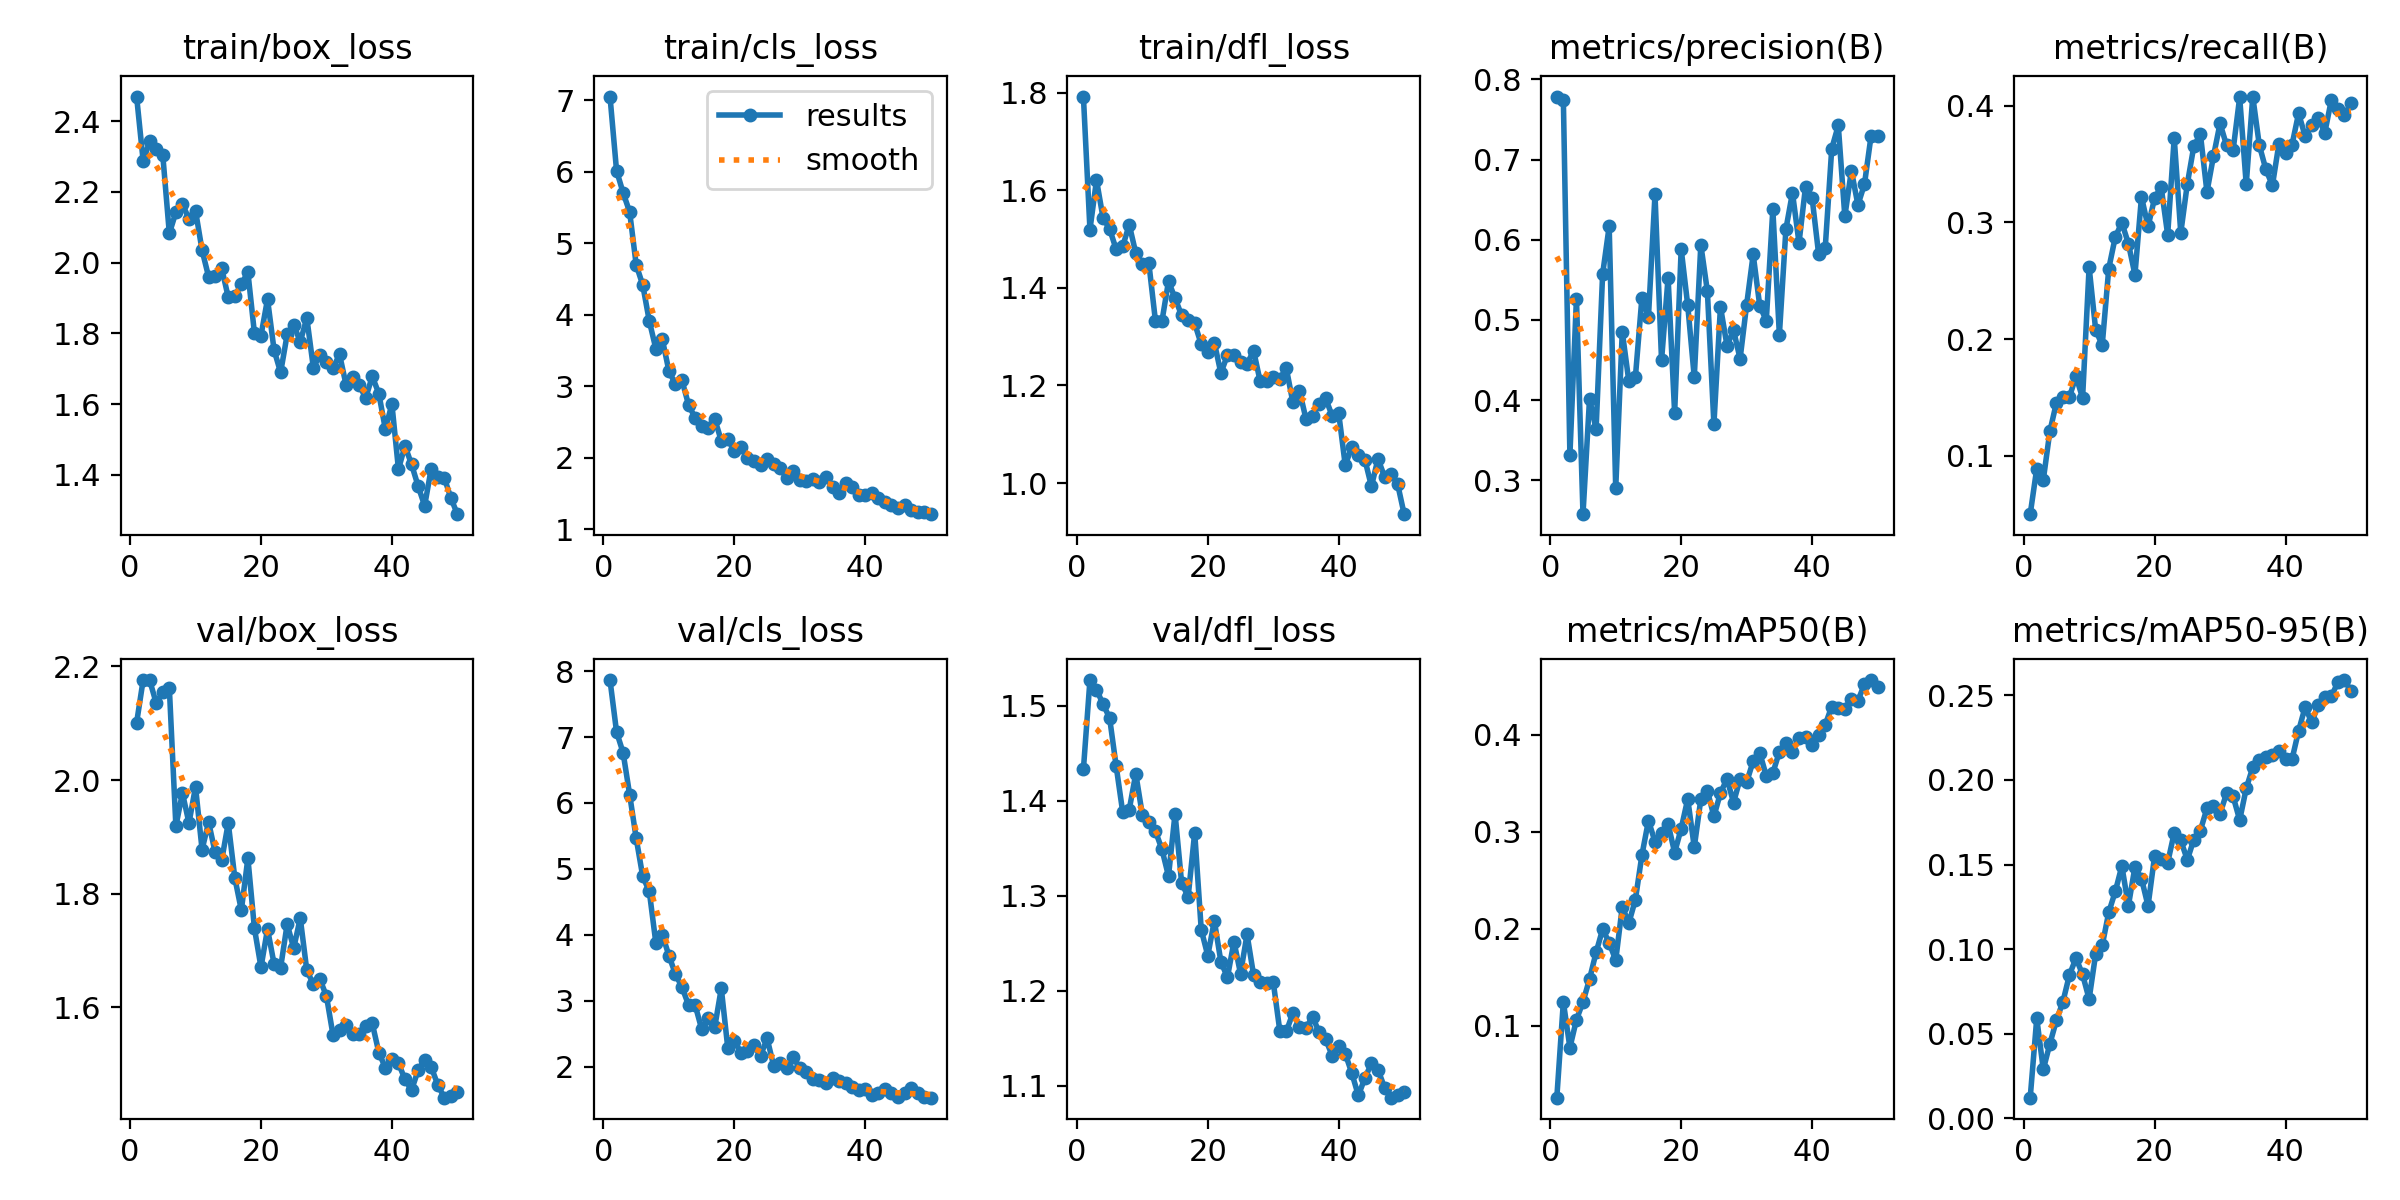

In [8]:
from IPython.display import display
from PIL import Image

img = Image.open("runs/detect/train/results.png")
display(img)

In [9]:
from ultralytics import YOLO

# Load your trained model
model = YOLO("runs/detect/train/weights/best.pt")

# Run prediction
results = model.predict(
    source="data",   # your images folder
    save=True,
    imgsz=640,
    conf=0.25
)


image 1/480 C:\Users\Pdllab\chimneyf\data\MAX_0441.JPG: 480x640 6 damages, 50.1ms
image 2/480 C:\Users\Pdllab\chimneyf\data\MAX_0442.JPG: 480x640 1 honeycombing, 4 damages, 31.6ms
image 3/480 C:\Users\Pdllab\chimneyf\data\MAX_0443.JPG: 480x640 5 damages, 33.7ms
image 4/480 C:\Users\Pdllab\chimneyf\data\MAX_0444.JPG: 480x640 4 damages, 37.7ms
image 5/480 C:\Users\Pdllab\chimneyf\data\MAX_0445.JPG: 480x640 4 damages, 33.5ms
image 6/480 C:\Users\Pdllab\chimneyf\data\MAX_0446.JPG: 480x640 3 honeycombings, 7 damages, 31.4ms
image 7/480 C:\Users\Pdllab\chimneyf\data\MAX_0447.JPG: 480x640 3 honeycombings, 1 rebar, 5 damages, 31.5ms
image 8/480 C:\Users\Pdllab\chimneyf\data\MAX_0448.JPG: 480x640 1 honeycombing, 2 damages, 32.7ms
image 9/480 C:\Users\Pdllab\chimneyf\data\MAX_0449.JPG: 480x640 1 damage, 31.6ms
image 10/480 C:\Users\Pdllab\chimneyf\data\MAX_0450.JPG: 480x640 1 honeycombing, 1 damage, 33.0ms
image 11/480 C:\Users\Pdllab\chimneyf\data\MAX_1555.JPG: 480x640 1 rebar, 31.3ms
image 12

In [10]:
import os
print(os.listdir("runs/detect/predict")[:5])

['MAX_0441.jpg', 'MAX_0442.jpg', 'MAX_0443.jpg', 'MAX_0444.jpg', 'MAX_0445.jpg']


In [17]:
from ultralytics import YOLO

# 1. Load your best trained model
model = YOLO("runs/detect/train/weights/best.pt")

# 2. Run validation to get detailed metrics
metrics = model.val()

# 3. Print the specific results
print(f"Mean Average Precision (mAP@50): {metrics.seg.map50}") # For segmentation
print(f"Precision: {metrics.seg.p}") # Precision per class
print(f"Recall: {metrics.seg.r}")    # Recall per class
print(f"F1-Score: {metrics.seg.f1}")  # F1-Score per class

Ultralytics 8.4.30  Python-3.13.9 torch-2.11.0+cpu CPU (11th Gen Intel Core i7-11700K @ 3.60GHz)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 1270.738.3 MB/s, size: 17332.5 KB)
val: Scanning C:\Users\Pdllab\chimneyf\dataset\labels\val.cache... 96 images, 37 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 96/96 1.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.7s/it 22.1s4.4ss
                   all         96        205       0.73      0.392      0.456      0.259
              spalling         21         25      0.751       0.24      0.324      0.167
          honeycombing         22         51      0.518       0.49      0.502      0.242
                 rebar         36         84      0.859       0.25      0.277      0.171
                damage         24         45      0.791      0.588       0.72      0.458
Speed: 1.3ms preproce

AttributeError: 'DetMetrics' object has no attribute 'seg'. See valid attributes below.
Utility class for computing detection metrics such as precision, recall, and mean average precision (mAP).

Attributes:
    names (dict[int, str]): A dictionary of class names.
    box (Metric): An instance of the Metric class for storing detection results.
    speed (dict[str, float]): A dictionary for storing execution times of different parts of the detection process.
    stats (dict[str, list]): A dictionary containing lists for true positives, confidence scores, predicted classes,
        target classes, and target images.
    nt_per_class: Number of targets per class.
    nt_per_image: Number of targets per image.

Methods:
    update_stats: Update statistics by appending new values to existing stat collections.
    process: Process predicted results for object detection and update metrics.
    clear_stats: Clear the stored statistics.
    keys: Return a list of keys for accessing specific met

In [18]:
from ultralytics import YOLO

# 1. Load the Segmentation-specific model
# This is a NEW model instance. It will not conflict with your 'model' from previous cells.
model_seg = YOLO("yolov8n-seg.pt") 

# 2. Start the new training
# This will create a NEW folder in 'runs/segment/train'
model_seg.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=4,       # You can try 4; if it crashes, change back to 2
    device="cpu",  # Keep as cpu if you don't have a GPU
    task="segment" # This ensures it looks for polygons, not just boxes
)

New https://pypi.org/project/ultralytics/8.4.31 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.30  Python-3.13.9 torch-2.11.0+cpu CPU (11th Gen Intel Core i7-11700K @ 3.60GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, 

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000153D2C27380>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004, 